In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import ast
from Bio.Seq import Seq
from Bio import SeqIO
import re
from pygenomeviz import GenomeViz
import matplotlib.pyplot as plt
from scipy.spatial import distance
import ast

In [2]:
#QC checked good AZFc regions
errDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/QC/LocationFiles/AZFc_QC_File.csv").drop(columns=['Unnamed: 0'])

In [3]:
colorDict={
    'blue':'#1307b3',
    'blue-plus':'#1307b3',
    'blue-IR1':'#1307b3',
    'teal':'#02a4a8',
    'green':'#00a115',
    'green-plus':'#00a115',
    'green-IR1':'#00a115',
    'red':'#940003',
    'gray':'#808080',
    'yellow':'#ffff00',
    'spacer':'white'}

In [4]:
colorList=[]
for color in errDF['colorblock']:
    if 'spacer' in color:
        colorList.append('spacer')
    elif 'plus' in color:
        color1 = color.split("-")[0][:-1]
        colorList.append(color1+'-plus')
    elif 'IR1' in color:
        color1 = color.split("-")[0][:-1]
        colorList.append(color1+'-IR1')
    else:
        colorList.append(color[:-1])
errDF['MainColor']=colorList
errDF['ColorHEX']=[colorDict[x] for x in colorList]

In [5]:
errDF[['sample','contig','start','end','orientation','MainColor','ColorHEX']].set_index("sample").to_csv("/ForDavid_Jan232026_FORGIVEME.csv")

In [6]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

In [7]:
def merge_coords_by_type(coord_list):
    if not coord_list:
        return []
    coord_list.sort(key=lambda x: x[0])
    merged = [coord_list[0]]

    for current in coord_list[1:]:
        last = merged[-1]
        if current[2] == last[2] and current[0] <= last[1]:
            merged[-1] = [last[0], max(last[1], current[1]), last[2]]
        else:
            merged.append(current)

    return merged

In [8]:
badSampleDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/Assemblies_wGaps_InColorRegions.csv").drop(columns=['Unnamed: 0'])
NgapDict={x:[] for x in set(badSampleDF['0'])}
for sample,start,end in zip(badSampleDF['0'],badSampleDF['2'],badSampleDF['3']):
    NgapDict[sample].append([start,end])

In [9]:
from typing import List, Optional
from Bio import Phylo

def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [10]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [11]:
haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

140


In [12]:
colorDict={
    'blue1':'#010f8e',
    'blue2':'#1307b3',
    'blue3':'#0000ff',
    'blue4':'#4f78ff',
    'teal1':'#02a4a8',
    'teal2':'#00eeff',
    'green1':'#00630d',
    'green2':'#00a115',
    'green3':'#00ff21',
    'red1':'#630002',
    'red2':'#940003',
    'red3':'#ff0005',
    'red4':'#ff4a4e',
    'gray1':'#808080',
    'gray2':'#bababa',
    'yellow1':'#8f8f00',
    'yellow2':'#ffff00',
    'spacer1':'white',
    'spacer2':'white',
    'spacer3':'white'}

In [13]:
colorDict={
    'blue1':'#1307b3',
    'blue2':'#1307b3',
    'blue3':'#1307b3',
    'blue4':'#1307b3',
    'teal1':'#02a4a8',
    'teal2':'#02a4a8',
    'green1':'#00a115',
    'green2':'#00a115',
    'green3':'#00a115',
    'red1':'#940003',
    'red2':'#940003',
    'red3':'#940003',
    'red4':'#940003',
    'gray1':'#808080',
    'gray2':'#808080',
    'yellow1':'#ffff00',
    'yellow2':'#ffff00',
    'spacer1':'white',
    'spacer2':'white',
    'spacer3':'white'}

In [14]:
hprc = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation.09302025_AllExonGenes.csv')
hprc['contigStart']=hprc['contigStart'].astype(int)
hprc['contigEnd']=hprc['contigEnd'].astype(int)
dazDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/HGSVC3_HPRC_CEPH_DAZ_RRM_CopyNumbers_09152025.csv").set_index("contig")
dazDF

,Unnamed: 0,sample,exonList
contig,,,
HG02984_chrY,0,HG02984,"[1, 2, 3, 1]"
HG01890_chrY,1,HG01890,"[1, 2, 1, 3]"
HG02647_chrY,2,HG02647,"[3, 1, 1, 2]"
HG02666_chrY,3,HG02666,"[3, 1, 1, 2]"
HG02668_chrY,4,HG02668,"[3, 1, 1, 2]"
...,...,...,...
HG00126_chrY,178,HG00126,"[3, 1, 1, 2]"
NA20752_chrY,179,NA20752,"[3, 1, 1, 2]"
HG01261_chrY,180,HG01261,"[3, 1]"


In [15]:
geneDF = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation.09302025_AllExonGenes.csv')
geneDF['contigStart']=geneDF['contigStart'].astype(int)
geneDF['contigEnd']=geneDF['contigEnd'].astype(int)

In [16]:
import json
with open('/LeeLab/HPRC/chromosomeY/Data/colorBlock_Clustering_Kmeans_09292025.json', 'r') as file:
        arrowDict = json.load(file)

In [17]:
len(set([x.split("_")[0] for x in arrowDict]))

104

In [18]:
genome_list = []
foundGeneList=[]
badGapSamples=[]
directory='/LeeLab/HPRC/chromosomeY/Data/ColorBlockDataframes_refined/'
for file in os.listdir(directory):
    if '.csv' in file:

        features2=()
        sampleName = str(file.split("_")[0])
        if sampleName in set(errDF['sample']):
            print(sampleName)
            df1 = pd.read_csv(directory+file).drop(columns=['Unnamed: 0'])

            if 'HG03456' in sampleName:
                mainContig = sampleName+"_chrY_"+str(str(file.split("_")[3]))
            else:
                mainContig = sampleName+"_chrY"
    
            df = df1[df1['Haplotype']==mainContig].copy()
            df['Cluster']='NONE'
            for row in df.index:
                contig = str(df.at[row, 'Haplotype'])
                start = int(df.at[row, 'StartCoordinate'])
                end = int(df.at[row, 'EndCoordinate'])
                try:
                    df.at[row,'Cluster']=arrowDict[contig+":"+str(start)+"-"+str(end)]
                except:
                    continue
                
            distances=[]
            flag=0
            for row in df.index:
                if flag==0:
                    distances.append(0)
                    previousEnd = int(df.at[row,'EndCoordinate'])
                    previousHaplotype=df.at[row,'Haplotype']
                    flag+=1
                else:
                    if df.at[row,'Haplotype'] == previousHaplotype:
                        distances.append(abs(int(df.at[row,'StartCoordinate'])-previousEnd))
                        previousEnd = int(df.at[row,'EndCoordinate'])
    
                    else:
                        distances.append(0)
                        previousEnd = int(df.at[row,'EndCoordinate'])
                        previousHaplotype=df.at[row,'Haplotype']
                        flag+=1
    
                        
            df['DistanceBetween']=distances
            
            colorList=[]
            for annotation in df['UniqueLengthMaxID']:
                if 'plus' in annotation or 'IR1' in annotation:
                    colorList.append(colorDict[annotation.split("-")[0]])
        
                elif 'spacer' in annotation:
                    colorList.append('white')
                else:
                    colorList.append(colorDict[annotation])
            df['Color']=colorList
    
            df['DAZ_RRMs']='NONE'
            try:
                for haplotype in set(df['Haplotype']):
                    
                    exonListNumbers = ast.literal_eval(str(dazDF.at[haplotype,'exonList']))
                    hapDF = df[df['Haplotype']==haplotype].copy()
                    count=0
                    
                    for row in hapDF.index:
                        if 'red' in str(hapDF.at[row,'UniqueLengthMaxID']):
                            testDF = geneDF[(geneDF['contig']==str(hapDF.at[row,'Haplotype'])) &(geneDF['geneName']=='DAZ1') &(geneDF['contigStart']<=int(hapDF.at[row,'EndCoordinate'])) &(geneDF['contigEnd']>=int(hapDF.at[row,'StartCoordinate']))].copy()
                            if len(testDF)==0:
                                continue
                            else:
                                df.at[row,'DAZ_RRMs']=exonListNumbers[count]
                                count+=1
    
            except:
                print(sampleName)
                continue
    
            tempGeneList=[]
            for dfrow in df.index:
                try:
                    if df.at[dfrow,'DAZ_RRMs']=='NONE':
        
                        haplotype = str(df.at[row,'Haplotype'])
                        blockEnd = int(df.at[dfrow,'EndCoordinate'])
                        blockStart = int(df.at[dfrow,'StartCoordinate'])
        
                        tempDF = hprc[(hprc['contig']==haplotype) & (hprc['contigStart']>=blockStart) & (hprc['contigEnd']<=blockEnd)].copy()
                        
                        if len(tempDF)>0:
                            for geneRow in tempDF.index:
                                if df.at[dfrow,'DAZ_RRMs']=='NONE':
                                    if pd.isna(tempDF.at[geneRow,'MaxLength_Liftoff_ID']):
                                        df.at[dfrow,'DAZ_RRMs']=str(tempDF.at[geneRow,'geneName'])
                                        tempGeneList.append(str(tempDF.at[geneRow,'geneName']))
                                    else:
                                        df.at[dfrow,'DAZ_RRMs']=str(tempDF.at[geneRow,'MaxLength_Liftoff_ID'])
                                        tempGeneList.append(str(tempDF.at[geneRow,'MaxLength_Liftoff_ID']))
                                else:
                                    continue
        
                        
                        else:
                            
                            tempgeneDF = hprc[(hprc['contig']==haplotype)].copy()
            
                            geneFoundList=[]
                            for geneerow in tempgeneDF.index:
                                geneStart = int(tempgeneDF.at[geneerow, 'contigStart'])
                                geneEnd = int(tempgeneDF.at[geneerow, 'contigEnd'])
                            
                                rangex = range(geneStart,geneEnd)
                                rangey = range(blockStart,blockEnd)
                                xs = set(rangex)
                                if len(xs.intersection(rangey))>1000:
                                    if pd.isna(tempgeneDF.at[geneerow,'MaxLength_Liftoff_ID']):
                                        geneFoundList.append(str(tempgeneDF.at[geneerow,'geneName']))
                                        
                                    else:
                                        geneFoundList.append(str(tempgeneDF.at[geneerow,'geneName']))
                                else:
                                    continue
        
                            if len(geneFoundList)==1 and df.at[dfrow,'DAZ_RRMs']=='NONE':
                                df.at[dfrow,'DAZ_RRMs']=geneFoundList[0]
                                tempGeneList.append(geneFoundList[0])
                            else:
                                continue
        
                    else:
                        continue
                except:
                    continue
                    
    
    
            df2 = df.copy()
            #break
            flaggg=0
            for row in df.index:
                if flaggg==0:
                    if df.at[row,'DistanceBetween']>1000000:
                        flaggg+=1
                        subtractDistance = int(df.at[row,'DistanceBetween'])-1000000
                        df2.at[row,'StartCoordinate'] = df.at[row,'StartCoordinate']-subtractDistance
                        df2.at[row,'EndCoordinate'] = df.at[row,'EndCoordinate']-subtractDistance
                    else:
                        continue
                else:
                    df2.at[row,'StartCoordinate'] = df.at[row,'StartCoordinate']-subtractDistance
                    df2.at[row,'EndCoordinate'] = df.at[row,'EndCoordinate']-subtractDistance
            
            start=1
            startCoordinate = min(df2['StartCoordinate'])-1
            totalsize= (max(df2['EndCoordinate']) - min(df2['StartCoordinate']))+100
            
            for row in df2.index:
                label = str(df2.at[row,'RefinedClassification'])
                start=int(df2.at[row,'StartCoordinate'])-startCoordinate
                end = int(df2.at[row,'EndCoordinate'])-startCoordinate
                color = str(df2.at[row,'Color'])
                cluster = str(df2.at[row,'Cluster'])
                    
            
                #Add the features
                if df2.at[row,'RefinedOrientation'] == 'antisense':
                    length = end-start
                    orientation=-1
                    features2 = add_feature(features2, (start, end, orientation, label, color,'Arrow',df2.at[row,'DAZ_RRMs'],cluster))
                else:
                    length = end-start
                    orientation=1
                    features2 = add_feature(features2, (start, end, orientation, label, color,'Arrow',df2.at[row,'DAZ_RRMs'],cluster))
    
            sampleGapFlag=0
            sampleBlockGapFlag=0
            if len(set(df2['GAP_TEST']))>1:
                sampleBlockGapFlag+=1
            else:
                pass
                
            if sampleName in NgapDict.keys():
                test1DF = df2[df2['EndCoordinate']<15000000].copy()
                test2DF = df2[df2['EndCoordinate']>=15000000].copy()
                if len(test1DF)>0:
                    for numberList in NgapDict[sampleName]:
                        x = range(int(numberList[0]),int(numberList[1]))
                        y = range(min(test1DF['StartCoordinate']),max(test1DF['EndCoordinate']))
                        xs = set(x)
                        if len(xs.intersection(y))>0:
                            sampleGapFlag+=1
                        else:
                            continue
                else:
                    pass
    
                if len(test2DF)>0:
                    for numberList in NgapDict[sampleName]:
                        x = range(int(numberList[0]),int(numberList[1]))
                        y = range(min(test2DF['StartCoordinate']),max(test2DF['EndCoordinate']))
                        xs = set(x)
                        if len(xs.intersection(y))>0:
                            sampleGapFlag+=1
                        else:
                            continue
                else:
                    pass
                    
            else:
                pass
    
            if sampleGapFlag>0 or sampleBlockGapFlag>0:
                badGapSamples.append(mainContig)
            else:
                for x in tempGeneList:
                    foundGeneList.append(x)
                genome_list.append(dict(name=mainContig, size=totalsize, features=features2))

HG02071
HG03579
HG01952
HG01934
NA18879
HG01255
HG02055
NA19650
HG00126
HG03065
HG01258
NA20752
HG01167
HG005
HG01928
HG01252
HG03017
NA18952
HG02129
NA18983
HG03732
HG03225
HG01099
HG03209
HG00512
NA20346
HG02056
HG01943
HG03009
HG01192
HG03130
HG00706
HG02953
NA19239
200085
HG02717
HG04160
HG02011
NA18612
HG00290
HG03248
HG02666
HG01505
HG04228
HG00731
NA12877
HG02083
HG02391
NA19443
HG01457
HG002
HG02074
HG02392
HG02040
HG02514
NA19331
200084
NA19317
NA18522
HG03371
HG00358
NA12886
NA20850
NA21093
HG02027
HG02965
HG01358
HG03139
HG01596
200080
HG03688
HG01890
HG01074
HG02572
HG02492
HG02738
HG03471
NA19705
HG04199
HG01109
NA19700
HG03521
HG00096
NA20509
NA18747
NA20905
HG02554
HG02135
NA12882
HG04204
NA18620
NA18974
HG04115
NA18608
HG00642
NA20870
NA19682
HG00609
HG00329
HG00621


In [19]:
import pandas as pd

def clean_adjacent_overlaps_as_tuples(
    df: pd.DataFrame,
    start_col=0,
    end_col=1,
    fix_end_if_needed=True,
    preserve_strings=True,
):
    """
    Adjust consecutive intervals so that if row i start overlaps previous row end
    (start <= prev_end), set start = prev_end + 1.

    Returns
    -------
    tuple[tuple]: each row as a tuple, in df order
    """
    out = df.copy()

    starts = pd.to_numeric(out[start_col], errors="coerce").to_numpy()
    ends   = pd.to_numeric(out[end_col],   errors="coerce").to_numpy()

    for i in range(1, len(out)):
        prev_end = ends[i - 1]
        cur_start = starts[i]

        if pd.isna(prev_end) or pd.isna(cur_start):
            continue

        if cur_start <= prev_end:
            starts[i] = prev_end + 1
            if fix_end_if_needed and not pd.isna(ends[i]) and starts[i] > ends[i]:
                ends[i] = starts[i]

    out[start_col] = starts.astype("Int64") if pd.isna(starts).any() else starts.astype(int)
    out[end_col]   = ends.astype("Int64")   if pd.isna(ends).any()   else ends.astype(int)

    if preserve_strings:
        for c in out.columns:
            if c in (start_col, end_col):
                continue
            if out[c].dtype == object:
                out[c] = out[c].astype(str)

    return tuple(tuple(row) for row in out.to_numpy())

In [20]:
genome_list2=[]
for group in genome_list:
    tempDF = pd.DataFrame(data=group['features'])
    df_clean = clean_adjacent_overlaps_as_tuples(tempDF, start_col=0, end_col=1)
    tempDict={'name':group['name'],'size':group['size'], 'features':df_clean}
    genome_list2.append(tempDict)

In [21]:
len(badGapSamples)

0

In [22]:
len(genome_list)

100

In [23]:
NewFeatureDF = {}
for genome in genome_list2:
    name, size, features = genome["name"], genome["size"], genome["features"]
    NewFeatureDF[name]={}
    for idx, featuree in enumerate(features, 1):
        start, end, strand, label, color, arrowStyle, dfRoww, cluster = featuree
        if dfRoww == 'NONE' and 'spacer3' not in label:
            continue
        else:
            if '-plus' in label or 'IR1-' in label: 
                continue
                label2 = label.split("-")[0] #[:-1]
                if str(label2)+"_"+str(dfRoww) not in NewFeatureDF[name]:
                    NewFeatureDF[name][str(label2)+"_"+str(dfRoww)]= {1:{'Start':start, 'End':end, 'Orientation':strand}}
                else:
                    additional = len(NewFeatureDF[name][str(label2)+"_"+str(dfRoww)])+1
                    NewFeatureDF[name][str(label2)+"_"+str(dfRoww)][additional] = {'Start':start, 'End':end, 'Orientation':strand}
            
            elif 'spacer' in label:
                if str(label)+"_"+str(dfRoww) not in NewFeatureDF[name]:
                    NewFeatureDF[name][str(label)+"_"+str(dfRoww)]= {1:{'Start':start, 'End':end, 'Orientation':strand}}
                else:
                    additional = len(NewFeatureDF[name][str(label)+"_"+str(dfRoww)])+1
                    NewFeatureDF[name][str(label)+"_"+str(dfRoww)][additional] = {'Start':start, 'End':end, 'Orientation':strand}
    
                    
            else:

                label2 = label[:-1]
                    
                if str(label2)+"_"+str(dfRoww) not in NewFeatureDF[name].keys():
                    NewFeatureDF[name][str(label2)+"_"+str(dfRoww)] = {1:{'Start':start, 'End':end, 'Orientation':strand, 'Cluster':cluster}}
                else:
                    additional = len(NewFeatureDF[name][str(label2)+"_"+str(dfRoww)])+1
                    NewFeatureDF[name][str(label2)+"_"+str(dfRoww)][additional] = {'Start':start, 'End':end, 'Orientation':strand, 'Cluster':cluster}

In [24]:
len(phylogeneticOrder)

142

In [150]:
#gv = GenomeViz()
import matplotlib as mpl
mpl.use('pdf')
mpl.rcParams['figure.facecolor']   = 'white'
mpl.rcParams['axes.facecolor']     = 'white'
mpl.rcParams['savefig.facecolor']  = 'white'
gv = GenomeViz(track_align_type="left", fig_track_height=.55,feature_track_ratio=0.5)
gv.set_scale_bar()

samplePairings=[]
tempList=[]
flag=0
samplesVisualized=0
sampleListVisualized=[]
used={}
skipThese=['NA12883','NA12884','HG03456','HG02602']
sampleCountKeep=[]
samplePairFlag=0
samplePairList=[]
samplePairs=[]
uniqueSampleArrows={}

for sample in phylogeneticOrder:

    if sample in used or sample in skipThese or sample not in set(errDF['sample']):
        continue
        
    else:
        
        used[sample]=1
        
        for genome in genome_list2:
            
            if sample in genome['name'] and genome['name'] not in used:
                used[genome['name']]=1

                if samplePairFlag==0:
                    samplePairList.append(genome['name'])
                    samplePairFlag=1
                else:
                    samplePairList.append(genome['name'])
                    samplePairs.append(samplePairList)
                    samplePairList=[genome['name']]


                sampleListVisualized.append(genome['name'])
                samplesVisualized+=1
                name, size, features = genome["name"], genome["size"], genome["features"]
                tempArrowList=[]
                
                track = gv.add_feature_track(name+"\n"+str(haplogroups[name.split("_")[0]]), size,labelsize=10, label_kws=dict(color='black'))
                for idx, featuree in enumerate(features, 1):
                    
                    start, end, strand, label, color, arrowStyle, dfRoww, cluster = featuree
                    
                    if end<start:
                        continue
                    else:
                        if str(cluster) == '0':
                            ecClusterColor = 'red'
                            
                        elif str(cluster) == '1':
                            ecClusterColor = 'cyan'

                        elif str(cluster) == '2':
                            ecClusterColor = 'lime'
                            
                        elif str(cluster) == '3':
                            ecClusterColor = 'magenta'

                        elif str(cluster) == '4':
                            ecClusterColor = 'yellow'

                        elif str(cluster) == '5':
                            ecClusterColor = 'orange'
                        
                        else:
                            ecClusterColor = 'white'
                            
                            
                        if str(dfRoww) == '2':
                            tempArrowList.append(str(strand)+"_"+color)
                            track.add_feature(start, end, strand, plotstyle="bigarrow", ec='black',fc=color,hatch="-----",lw=.5, text_kws=dict(color='white',rotation=0, vpos="center", hpos="center", size=.5))
                        elif str(dfRoww) == '3':
                            tempArrowList.append(str(strand)+"_"+color)
                            track.add_feature(start, end, strand, plotstyle="bigarrow", ec='black',fc=color,hatch="/////",lw=.5, text_kws=dict(color='white',rotation=0, vpos="center", hpos="center", size=.5))
                        elif str(dfRoww) == '0':
                            tempArrowList.append(str(strand)+"_"+color)
                            track.add_feature(start, end, strand, plotstyle="bigarrow", ec='black',fc=color,hatch="ooo",lw=.5, text_kws=dict(color='white',rotation=0, vpos="center", hpos="center", size=.5))
                        elif str(dfRoww) == '1':
                            tempArrowList.append(str(strand)+"_"+color)
                            track.add_feature(start, end, strand, plotstyle="bigarrow", ec='black',fc=color,lw=.5, text_kws=dict(color='white',rotation=0, vpos="center", hpos="center", size=.5))
                        else:
                            if 'IR1' in label or 'spacer' in label or 'plus' in label or ecClusterColor == 'white':
                                track.add_feature(start, end, strand, ec='black',plotstyle="bigarrow", fc=color,lw=.5, text_kws=dict(color='white',rotation=0, vpos="center", hpos="center", size=.5))

                            else:
                                tempArrowList.append(str(strand)+"_"+color)
                                track.add_feature(start, end, strand, plotstyle="bigarrow", ec='black', fc=color,lw=.5, text_kws=dict(color='white',rotation=0, vpos="center", hpos="center", size=.5))
                joinedName = '_'.join(tempArrowList)
                if joinedName in uniqueSampleArrows:
                    uniqueSampleArrows[joinedName].append(name)
                else:
                    uniqueSampleArrows[joinedName]=[name]

gv.savefig("/AZFc_Clusterings.pdf")

N valid samples: 100
N ordered genomes: 100
First 20 track sample IDs: ['HG01890', 'HG02666', 'HG03225', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'NA19239', 'HG01074', 'HG01109', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02965']
global_size: 6185688
Saved /LeeLab/HPRC/chromosomeY/Figures/AZFc/AZFc_Submission/AZFc_allSamples_Jan232026_page1.pdf
Saved /LeeLab/HPRC/chromosomeY/Figures/AZFc/AZFc_Submission/AZFc_allSamples_Jan232026_page2.pdf
Saved /LeeLab/HPRC/chromosomeY/Figures/AZFc/AZFc_Submission/AZFc_allSamples_Jan232026_page3.pdf
Saved /LeeLab/HPRC/chromosomeY/Figures/AZFc/AZFc_Submission/AZFc_allSamples_Jan232026_page4.pdf


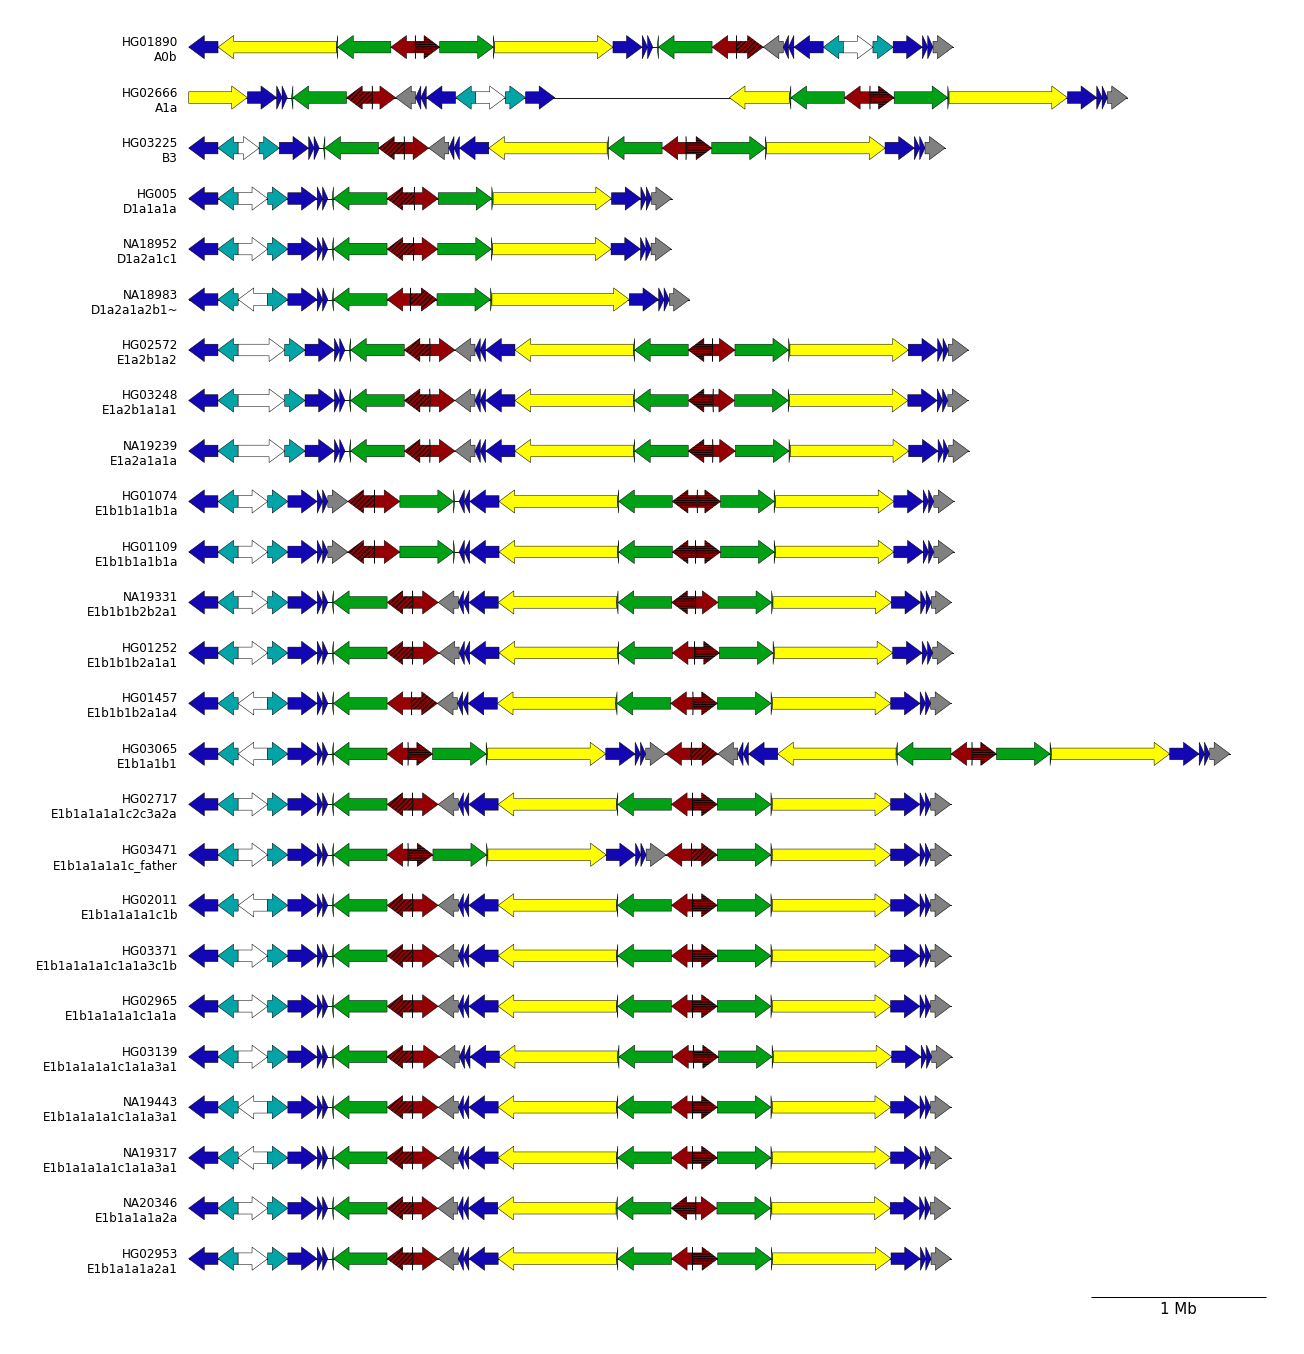

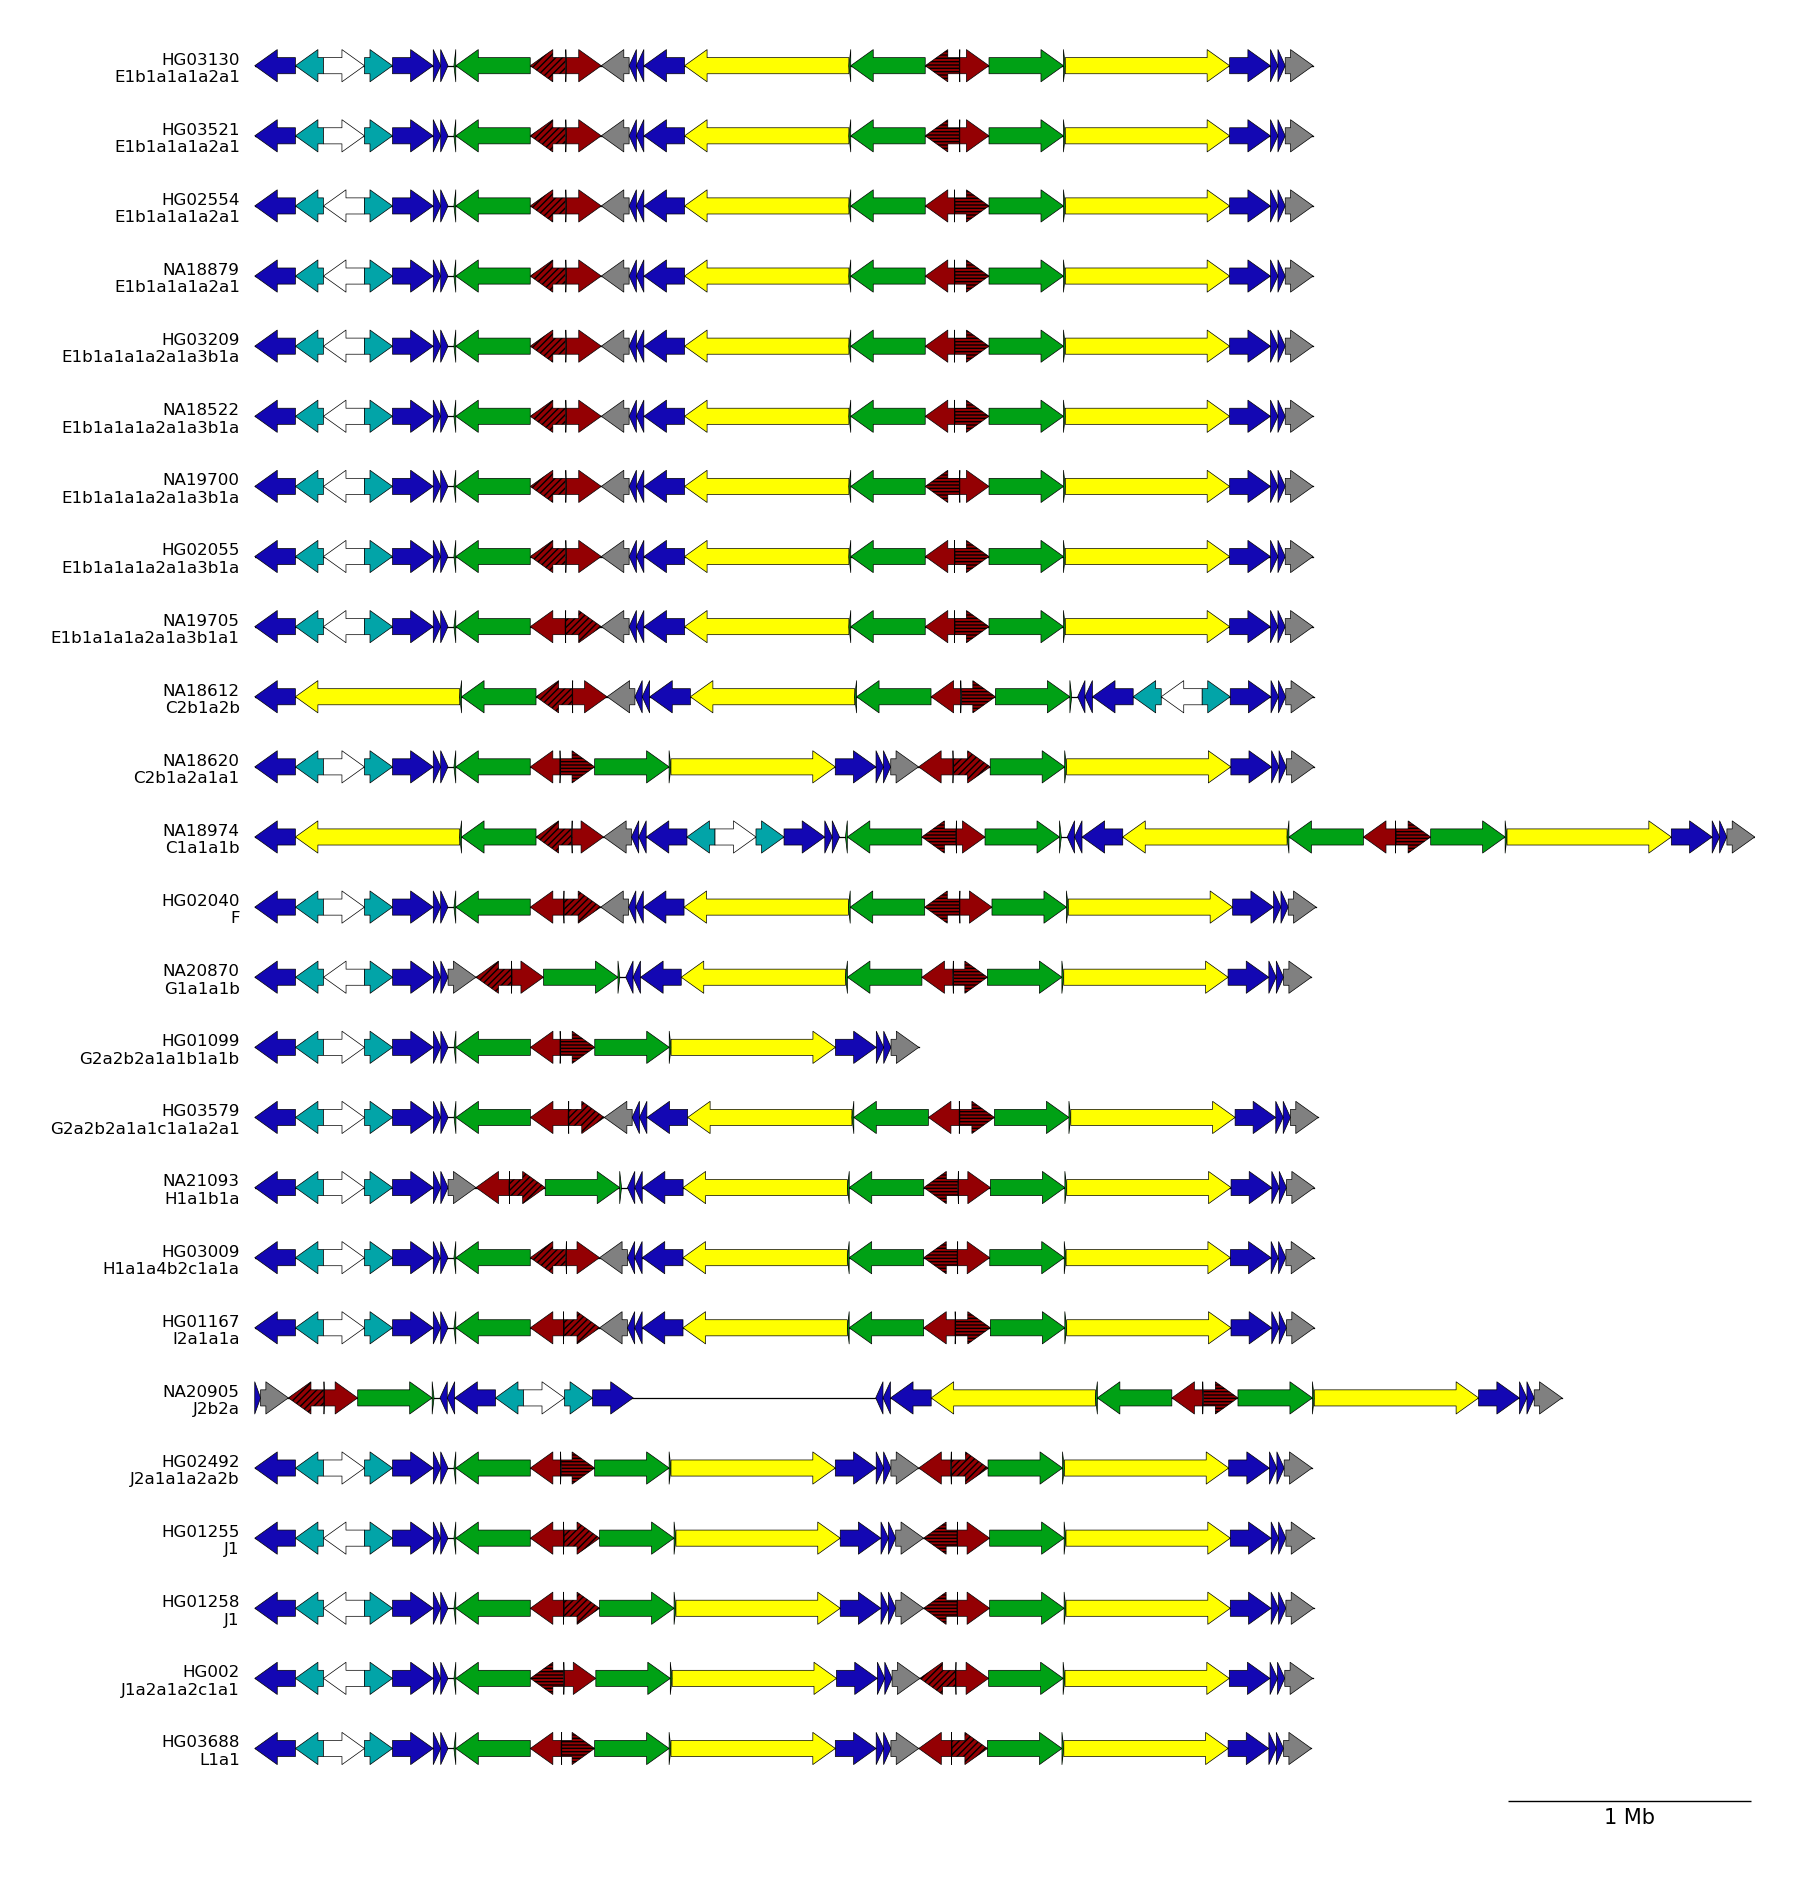

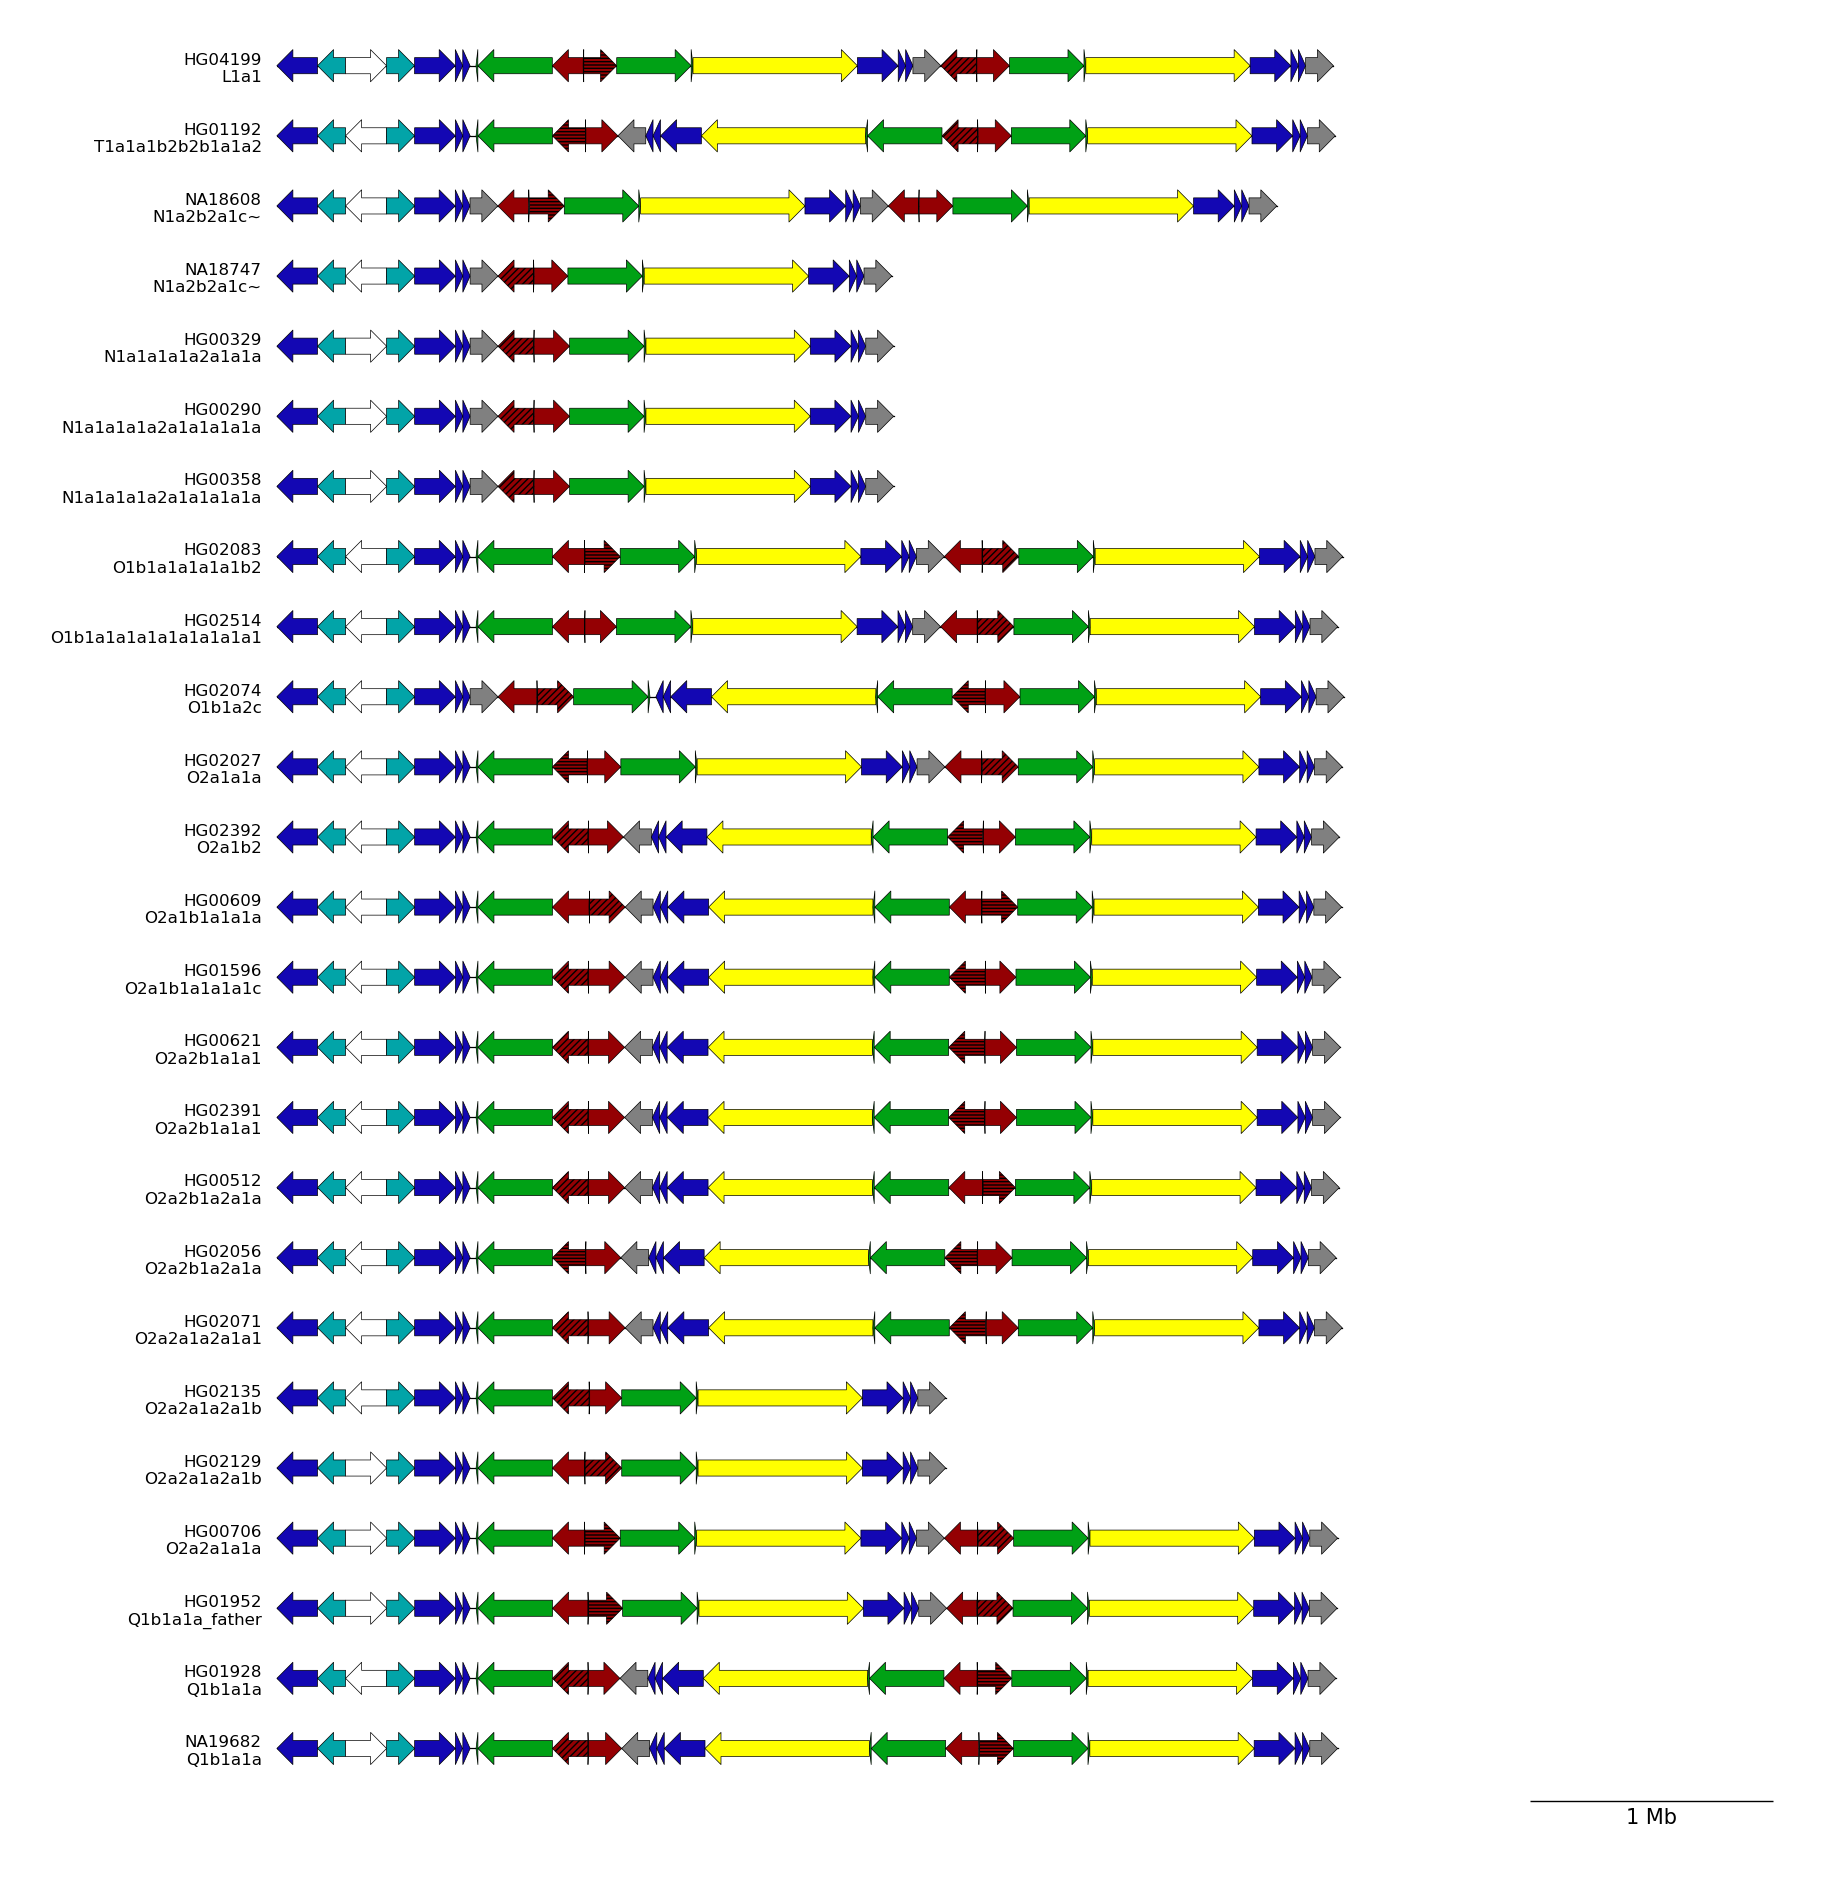

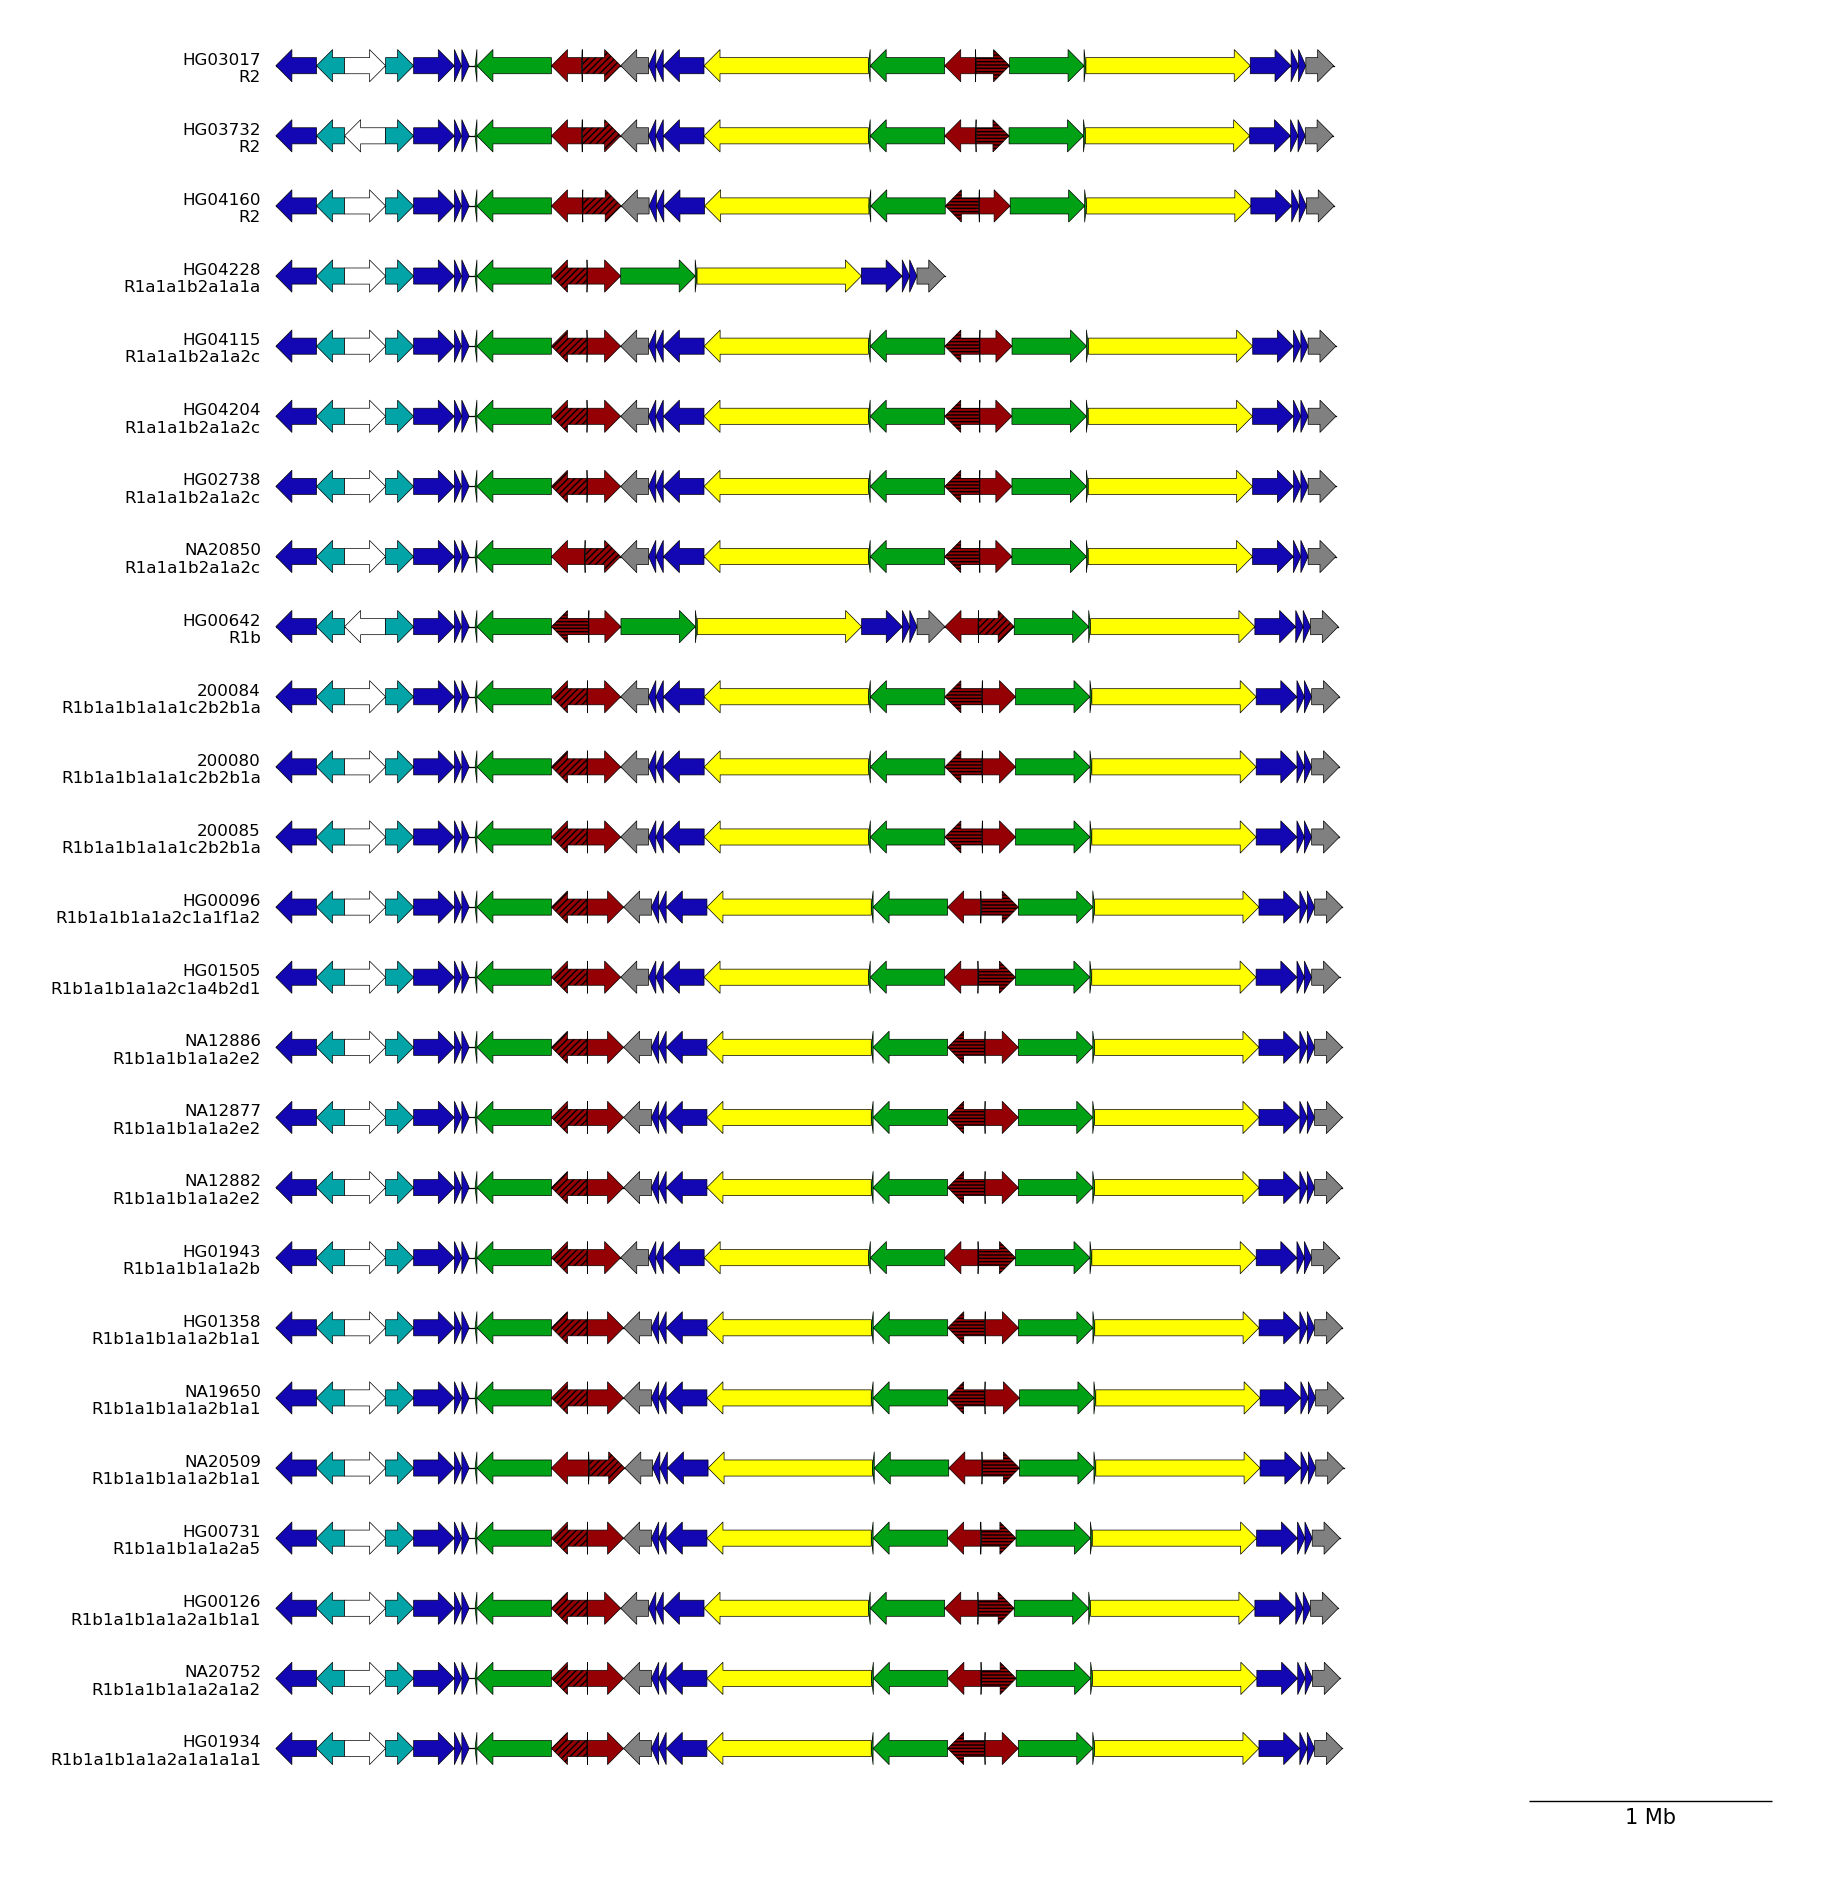

In [25]:
import math
import matplotlib as mpl
from pygenomeviz import GenomeViz

mpl.use("pdf")
mpl.rcParams["figure.facecolor"]  = "white"
mpl.rcParams["axes.facecolor"]    = "white"
mpl.rcParams["savefig.facecolor"] = "white"

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

skipThese = {"NA12883", "NA12884", "HG03456", "HG02602"}
Npages = 4 
BASELINE_LW = 0.9

SCALE_BP = 1_000_000
SCALE_LABEL = "1 Mb"
SCALE_LABELSIZE = 15
SCALE_YMARGIN = 1.0
# ---------------------------------------------

valid_samples = [
    s for s in phylogeneticOrder
    if (s not in skipThese) and (s in set(errDF["sample"]))
]

sample2genomes = {}
for genome in genome_list2:
    gname = str(genome.get("name", ""))
    sample_key = gname.split("_")[0]  
    if sample_key in valid_samples:
        sample2genomes.setdefault(sample_key, []).append(genome)

ordered_genomes = []
seen_genomes = set()
for sample in valid_samples:
    genomes_for_sample = sorted(sample2genomes.get(sample, []), key=lambda g: str(g.get("name", "")))
    for genome in genomes_for_sample:
        gname = str(genome.get("name", ""))
        if gname in seen_genomes:
            continue
        seen_genomes.add(gname)
        ordered_genomes.append(genome)

print("N valid samples:", len(valid_samples))
print("N ordered genomes:", len(ordered_genomes))
print("First 20 track sample IDs:", [g["name"].split("_")[0] for g in ordered_genomes[:20]])

global_size = max(int(g["size"]) for g in ordered_genomes) if ordered_genomes else 1
print("global_size:", global_size)

# Split into N pages
per_fig = math.ceil(len(ordered_genomes) / Npages) if ordered_genomes else 1

uniqueSampleArrows = {}

for page_idx, genome_chunk in enumerate(chunks(ordered_genomes, per_fig), start=1):

    gv = GenomeViz(track_align_type="left", fig_track_height=0.35, feature_track_ratio=0.85)

    gv.set_scale_bar(
        scale_size_label=(SCALE_BP, SCALE_LABEL),
        labelsize=SCALE_LABELSIZE,
        ymargin=SCALE_YMARGIN,
    )

    for genome in genome_chunk:
        name = genome["name"]
        features = genome["features"]

        hg_key = name.split("_")[0]
        hap = haplogroups.get(hg_key, "")
        track_label = f"{hg_key}\n{hap}"

        last_end = 0
        for featuree in features:
            start, end, strand, label, color, arrowStyle, dfRoww, cluster = featuree
            try:
                start = int(start)
                end = int(end)
            except Exception:
                continue
            if end >= start:
                last_end = max(last_end, end)

        track_size = last_end if last_end > 0 else int(genome["size"])
        track_size = max(1, int(track_size))

        track = gv.add_feature_track(
            track_label,
            track_size,
            labelsize=12,
            label_kws=dict(color="black"),
            line_kws=dict(color="black", lw=BASELINE_LW, alpha=1.0),  # SHOW baseline
        )

        tempArrowList = []

        for idx, featuree in enumerate(features, 1):
            start, end, strand, label, color, arrowStyle, dfRoww, cluster = featuree
            try:
                start = int(start)
                end = int(end)
            except Exception:
                continue
            if end < start:
                continue

            if str(cluster) == "0":
                ecClusterColor = "red"
            elif str(cluster) == "1":
                ecClusterColor = "cyan"
            elif str(cluster) == "2":
                ecClusterColor = "lime"
            elif str(cluster) == "3":
                ecClusterColor = "magenta"
            elif str(cluster) == "4":
                ecClusterColor = "yellow"
            elif str(cluster) == "5":
                ecClusterColor = "orange"
            else:
                ecClusterColor = "white"

            if str(dfRoww) == "2":
                tempArrowList.append(f"{strand}_{color}")
                track.add_feature(
                    start, end, strand,
                    plotstyle="bigarrow",
                    ec="black", fc=color, hatch="-----", lw=0.5,
                    text_kws=dict(color="white", rotation=0, vpos="center", hpos="center", size=0.5),
                )

            elif str(dfRoww) == "3":
                tempArrowList.append(f"{strand}_{color}")
                track.add_feature(
                    start, end, strand,
                    plotstyle="bigarrow",
                    ec="black", fc=color, hatch="/////", lw=0.5,
                    text_kws=dict(color="white", rotation=0, vpos="center", hpos="center", size=0.5),
                )

            elif str(dfRoww) == "0":
                tempArrowList.append(f"{strand}_{color}")
                track.add_feature(
                    start, end, strand,
                    plotstyle="bigarrow",
                    ec="black", fc=color, hatch="ooo", lw=0.5,
                    text_kws=dict(color="white", rotation=0, vpos="center", hpos="center", size=0.5),
                )

            elif str(dfRoww) == "1":
                tempArrowList.append(f"{strand}_{color}")
                track.add_feature(
                    start, end, strand,
                    plotstyle="bigarrow",
                    ec="black", fc=color, lw=0.5,
                    text_kws=dict(color="white", rotation=0, vpos="center", hpos="center", size=0.5),
                )

            else:
                if ("IR1" in str(label)) or ("spacer" in str(label)) or ("plus" in str(label)) or (ecClusterColor == "white"):
                    track.add_feature(
                        start, end, strand,
                        plotstyle="bigarrow",
                        ec="black", fc=color, lw=0.5,
                        text_kws=dict(color="white", rotation=0, vpos="center", hpos="center", size=0.5),
                    )
                else:
                    tempArrowList.append(f"{strand}_{color}")
                    track.add_feature(
                        start, end, strand,
                        plotstyle="bigarrow",
                        ec="black", fc=color, lw=0.5,
                        text_kws=dict(color="white", rotation=0, vpos="center", hpos="center", size=0.5),
                    )

        joinedName = "_".join(tempArrowList)
        uniqueSampleArrows.setdefault(joinedName, []).append(name)

    fig = gv.plotfig()
    for ax in fig.axes:
        if ax.has_data():
            ax.set_xlim(0, global_size)

    out_pdf = f"/LeeLab/HPRC/chromosomeY/Figures/AZFc/AZFc_Submission/AZFc_allSamples_Jan232026_page{page_idx}.pdf"
    out_jpg = f"/LeeLab/HPRC/chromosomeY/Figures/AZFc/AZFc_Submission/AZFc_allSamples_Jan232026_Clusterings_page{page_idx}.jpg"
    fig.savefig(out_pdf)
    fig.savefig(out_jpg, dpi=300)
    print("Saved", out_pdf)


In [136]:
uniqueSampleList = {y[0]:len(y) for x,y in uniqueSampleArrows.items()}

In [137]:
Group=1
with open('/UniqueAZFc_Structures.tsv', 'w') as file:
    for key in uniqueSampleArrows:
        for sample in uniqueSampleArrows[key]:
            file.write("Architecture:"+str(Group)+"\t"+str(sample)+'\t'+str(key)+'\n')

        Group+=1
file.close()

In [138]:
len(uniqueSampleArrows)

12

In [139]:
len(uniqueSampleList)

12

In [140]:
sum(uniqueSampleList.values())

100

In [142]:
import json
#export the dictionary out so that it can be used in visualization
#with open('/LeeLab/HPRC/chromosomeY/Data/uniqueColorblock_99_samples.json', 'w') as f:
#    json.dump(uniqueSampleArrows, f)

In [143]:
len(uniqueSampleArrows)

12

In [144]:
def keys_sorted_by_value(d, descending=True):
    """
    Return keys sorted by their numeric values.

    descending=True  -> largest to smallest
    descending=False -> smallest to largest
    """
    return [k for k, v in sorted(d.items(), key=lambda kv: kv[1], reverse=descending)]


uniqueSampleOrderList={}
for sample in uniqueSampleList:
    for genome in genome_list2:
        if sample == genome['name']:
            uniqueSampleOrderList[sample]=genome['size']

mySortedSampleList = keys_sorted_by_value(uniqueSampleOrderList)

In [145]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update({
    "pdf.fonttype": 42,  
    "ps.fonttype": 42,   
    "svg.fonttype": "none"  
})

mpl.rcParams["font.family"] = "Arial"

In [146]:
#gv = GenomeViz()
mpl.use('pdf')
mpl.rcParams['figure.facecolor']   = 'white'
mpl.rcParams['axes.facecolor']     = 'white'
mpl.rcParams['savefig.facecolor']  = 'white'
gv = GenomeViz(track_align_type="left", fig_track_height=.25,feature_track_ratio=1.3)
gv.set_scale_bar(ymargin=0.6, labelsize=14, scale_size_label=(1_000_000, "1Mb"))

samplePairings=[]
tempList=[]
flag=0
samplesVisualized=0
sampleListVisualized=[]
used={}
skipThese=[]
samplePairFlag=0
samplePairList=[]
samplePairs=[]
OUTLINE_LW = 1.2

groupNumber=1
for presample in mySortedSampleList:
    sample = presample.split("_")[0]

    if sample in used or sample in skipThese:
        continue
        
    else:
        print(sample,groupNumber)
        used[sample]=1
        
        for genome in genome_list2:
            if presample in genome['name'] and genome['name'] not in used:
                print(sample,groupNumber)
                used[genome['name']]=1

                sampleListVisualized.append(genome['name'])
                samplesVisualized+=1
                name, size, features = genome["name"], genome["size"], genome["features"]
                
                track = gv.add_feature_track('Group: '+str(groupNumber)+'\nn='+str(uniqueSampleList[presample]), size,labelsize=10, label_kws=dict(color='black'))
                groupNumber+=1
                
                for idx, featuree in enumerate(features, 1):
                    
                    start, end, strand, label, color, arrowStyle, dfRoww, cluster = featuree
                    
                    if end<start:
                        continue
                    else:
                            
                        if str(dfRoww) == '2':
                            track.add_feature(start, end, strand, plotstyle="bigarrow", fc=color,lw=OUTLINE_LW, text_kws=dict(color='black',rotation=0, vpos="center", hpos="center", size=.5))
                        elif str(dfRoww) == '3':
                            track.add_feature(start, end, strand, plotstyle="bigarrow", fc=color,lw=OUTLINE_LW, text_kws=dict(color='black',rotation=0, vpos="center", hpos="center", size=.5))
                        elif str(dfRoww) == '0':
                            track.add_feature(start, end, strand, plotstyle="bigarrow", fc=color,lw=OUTLINE_LW, text_kws=dict(color='black',rotation=0, vpos="center", hpos="center", size=.5))
                        elif str(dfRoww) == '1':
                            track.add_feature(start, end, strand, plotstyle="bigarrow", fc=color,lw=OUTLINE_LW, text_kws=dict(color='black',rotation=0, vpos="center", hpos="center", size=.5))
                        else:
                            if 'IR1' in label or 'plus' in label or 'spacer' in label:
                                track.add_feature(start, end, strand, plotstyle="bigarrow", fc=color,lw=OUTLINE_LW, text_kws=dict(color='black',rotation=0, vpos="center", hpos="center", size=.5))
                            else:
                                track.add_feature(start, end, strand, plotstyle="bigarrow", fc=color,lw=OUTLINE_LW, text_kws=dict(color='black',rotation=0, vpos="center", hpos="center", size=.5))          

                                
#gv.savefig("/UniqueSubset_AZFc_Jan222026.pdf")
#gv.savefig("/UniqueSubset_AZFc_Jan222026.jpeg", dpi=300)

NA18974 1
NA18974 1
HG03065 2
HG03065 2
NA20905 3
NA20905 3
HG02666 4
HG02666 4
HG01074 5
HG01074 5
HG01890 6
HG01890 6
NA18612 7
NA18612 7
HG03471 8
HG03471 8
HG03225 9
HG03225 9
NA18608 10
NA18608 10
HG005 11
HG005 11
HG00290 12
HG00290 12
